## Fashion MNIST dataset으로 이미지 분류 모델

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(60000, 28, 28)   (60000,)
(10000, 28, 28)   (10000,)
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


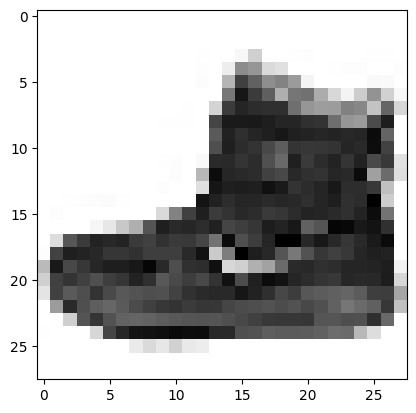

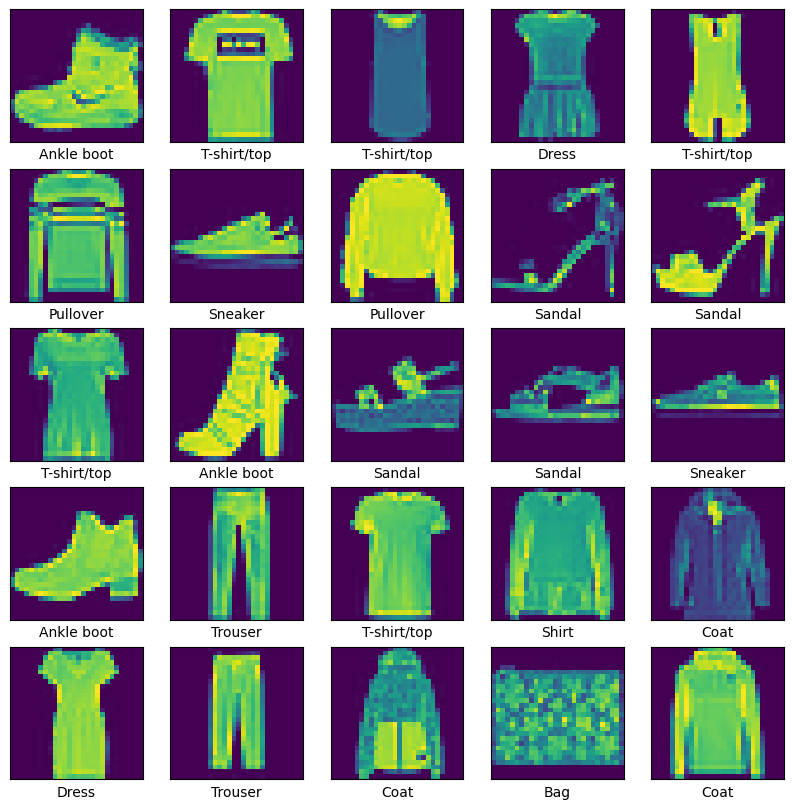

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print(train_images.shape, ' ', train_labels.shape)  # (60000, 28, 28)   (60000,)
print(test_images.shape, ' ', test_labels.shape)    # (10000, 28, 28)   (10000,)
print(set(train_labels))

plt.imshow(train_images[0], cmap='Greys')
plt.show()

# 25개의 이미지 확인
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(class_names[train_labels[i]])
    plt.imshow(train_images[i])
plt.show()

# 데이터 값 조정

In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0
print(train_images[0])

# model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu'),   # 완전(밀집) 연결
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])
print(model.summary())

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

In [4]:
model.fit(train_images, train_labels, batch_size=64, epochs=10, verbose=1)

test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy: ', test_acc)
print('Test loss: ', test_loss)

Epoch 1/10
938/938 [==============================] - 3s 2ms/step - loss: 0.5232 - accuracy: 0.8162
Epoch 2/10
938/938 [==============================] - 2s 2ms/step - loss: 0.3794 - accuracy: 0.8620
Epoch 3/10
938/938 [==============================] - 2s 2ms/step - loss: 0.3408 - accuracy: 0.8754
Epoch 4/10
938/938 [==============================] - 2s 2ms/step - loss: 0.3141 - accuracy: 0.8853
Epoch 5/10
938/938 [==============================] - 2s 2ms/step - loss: 0.2981 - accuracy: 0.8901
Epoch 6/10
938/938 [==============================] - 2s 2ms/step - loss: 0.2820 - accuracy: 0.8952
Epoch 7/10
938/938 [==============================] - 2s 2ms/step - loss: 0.2710 - accuracy: 0.8992
Epoch 8/10
938/938 [==============================] - 4s 4ms/step - loss: 0.2596 - accuracy: 0.9022
Epoch 9/10
938/938 [==============================] - 5s 5ms/step - loss: 0.2506 - accuracy: 0.9064
Epoch 10/10
313/313 [==============================] - 2s 4ms/step - loss: 0.3532 - accuracy: 0.8789

# 예측

313/313 [==============================] - 1s 1ms/step
[2.8269190e-08 5.3554021e-07 1.2379734e-07 1.4880591e-09 1.0539716e-06
 8.8650623e-04 3.4913265e-07 1.0062825e-02 1.2577696e-07 9.8904848e-01]
예측값:  9
실제값:  9


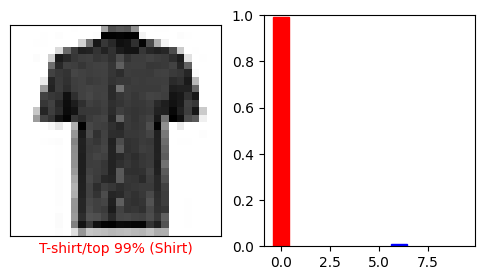

In [5]:
pred = model.predict(test_images)
print(pred[0])
print('예측값: ',np.argmax(pred[0]))
print('실제값: ',test_labels[0])

# 각 이미지 출력용 함수 (예측 이미지와 레이블을 비교)
def plot_image(i, pred_arr, true_label, img):
    pred_arr, true_label, img = pred_arr[i], true_label[i], img[i]
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap='Greys')
    
    pred_label = np.argmax(pred_arr)
    # 예측값과 실제값이 같으면 blue, 다르면 red
    if pred_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    
    plt.xlabel('{} {:2.0f}% ({})'.format(class_names[pred_label], 100 * np.max(pred_arr), class_names[true_label]), color=color)

i = 40
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(i, pred, test_labels, test_images)

def plot_value_arr(i, pred_arr, true_label):
    pred_arr, true_label = pred_arr[i], true_label[i]
    thisplot = plt.bar(range(10), pred_arr)
    plt.ylim([0, 1])
    pred_label = np.argmax(pred_arr)
    thisplot[pred_label].set_color('red')   # 예측값
    thisplot[true_label].set_color('blue')  # 실제값

plt.subplot(1, 2, 2)
plot_value_arr(i, pred, test_labels)

plt.show()